In [1]:
from functools import partial
import matplotlib.pyplot as plt
import cupy as cp
from superfv import HydroSolver, ics, TimeIntegrator, BC, vis
from teyssier.sedov import sedovana

In [2]:
# Initialize simulation
N = 128
sim = HydroSolver(
    ic=partial(ics.sedov, gamma=1.4, h=1 / N),
    nx=N,
    ny=N,
    nz=N,
    bcx=(BC.REFLECTIVE, BC.FREE),
    bcy=(BC.REFLECTIVE, BC.FREE),
    bcz=(BC.REFLECTIVE, BC.FREE),
    p=1,
    use_MUSCL=True,
    cupy=True,
)

In [3]:
# Run simulation
sim.run(1e-3, time_integrator=TimeIntegrator.MUSCL_HANCOCK, allow_overshoot=True)

SuperFV: 94 steps | t=1.00e-03/1.00e-03, dt=1.30e-05 | rho_min=9.69e-03 | E_cons=2.33e-10 | wall=1.94e+00s (done)


In [4]:
# Print timing results
n_steps = sim.step_history[-1].step
n_xyz = sim.params.mesh.nx * sim.params.mesh.ny * sim.params.mesh.nz
t_take_step = sim.step_history.get_total_time("take_step")
update_rate = n_steps * n_xyz / t_take_step

t_compute_dt = sim.step_history.get_total_time("compute_dt")
t_update_unew = sim.step_history.get_total_time("update_unew")
t_update_W = sim.step_history.get_total_time("update_W")
t_update_fluxes = sim.step_history.get_total_time("update_fluxes")
t_riemann_solver = sim.step_history.get_total_time("riemann_solver")
t_update_dudt = sim.step_history.get_total_time("update_dudt")

print(f"  update_rate = {update_rate:8.2e} cell/s\n")
print(f"    compute_dt: {t_compute_dt/t_take_step * 100:8.2f} %")
print(f"   update_unew: {t_update_unew/t_take_step * 100:8.2f} %")
print(f"        update_W: {t_update_W/t_take_step * 100:8.2f} %")
print(f"   update_fluxes: {t_update_fluxes/t_take_step * 100:8.2f} %")
print(f"    riemann_solver: {t_riemann_solver/t_take_step * 100:8.2f} %")
print(f"     update_dudt: {t_update_dudt/t_take_step * 100:8.2f} %")

  update_rate = 1.04e+08 cell/s

    compute_dt:     3.77 %
   update_unew:    95.50 %
        update_W:     9.91 %
   update_fluxes:    76.18 %
    riemann_solver:     5.49 %
     update_dudt:     6.99 %


In [5]:
# Compute shell averages of density
r_edges = cp.linspace(0, 1, 64)

X = sim.mesh.array_manager["core_X"]
Y = sim.mesh.array_manager["core_Y"]
Z = sim.mesh.array_manager["core_Z"]
rho = cp.asarray(sim.snapshot_history[-1].u[sim.idx("rho")])

rho_binned, r_centers = vis.shell_average(rho, X, Y, Z, (0, 0, 0), r_edges)

In [6]:
# Compute analytical solution
dim = 3
E0 = 1
rho0 = 1
T = sim.step_history[-1].t_sim

r, d, u, P = sedovana(1.4, dim)

r *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (2 / (dim + 2))
d *= rho0
u *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (-dim / (dim + 2))
P *= (E0 / rho0) ** (2.0 / (dim + 2)) * T ** (-2 * dim / (dim + 2)) * rho0

chi0=np.float64(1.030904745855628)


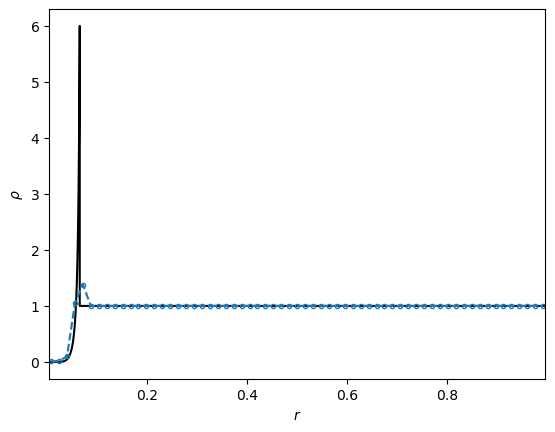

In [7]:
# Plot analytical solution against cell averages
plt.xlim(sim.mesh.x_centers[0], sim.mesh.x_centers[-1])
plt.xlabel(r"$r$")
plt.ylabel(r"$\rho$")
plt.plot(r, d, "k", label="Analytical")
plt.plot(r_centers, rho_binned, linestyle="--", marker=".", mfc="none", label="superfv")

Text(0.5, 0, '$t$')

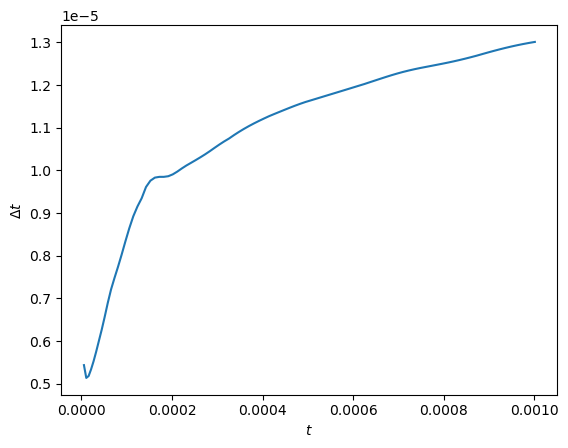

In [8]:
plt.plot(sim.step_history.get_history("t_sim"), sim.step_history.get_history("dt"))
plt.ylabel(r"$\Delta t$")
plt.xlabel(r"$t$")